# **1.BUKA COLAB & HUBUNGKAN DRIVE**

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **2.IMPORT LIBRARY**

In [13]:
import cv2
import os
import numpy as np
import pandas as pd

from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# **3.SET PATH**

In [14]:
import os
print(os.listdir('/content/drive/MyDrive/SEMESTER 6/COMVIS/UTS/lemon_dataset'))

['good_quality', 'bad_quality']


# **4.EKSTRAKSI HSV (WARNA)**

In [15]:
def extract_hsv(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (128,128))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h_mean = np.mean(hsv[:,:,0])
    s_mean = np.mean(hsv[:,:,1])
    v_mean = np.mean(hsv[:,:,2])

    return [h_mean, s_mean, v_mean]

# **5.EKSTRAKSI GLCM (TEKSTUR)**

In [16]:
def extract_glcm(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (128,128))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast').mean()
    energy = graycoprops(glcm, 'energy').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()

    return [contrast, energy, homogeneity]

# **6.AMBIL DATA DARI FOLDER**

In [17]:
import os

data = []
labels = []

base_path = '/content/drive/MyDrive/SEMESTER 6/COMVIS/UTS/lemon_dataset'

for label in ['good_quality', 'bad_quality']:
    folder_path = os.path.join(base_path, label)

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)

        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        hsv = extract_hsv(img_path)
        glcm = extract_glcm(img_path)

        features = hsv + glcm
        data.append(features)

        if label == 'good_quality':
            labels.append(1)
        else:
            labels.append(0)

import pandas as pd
df = pd.DataFrame(data, columns=[
    'H','S','V',
    'contrast','energy','homogeneity'
])

df['label'] = labels

print("Jumlah data:", len(df))
df.head()

Jumlah data: 2076


,H,S,V,contrast,energy,homogeneity,label
0,28.882935,104.454773,148.514709,220.669792,0.014032,0.146571,1
1,31.815735,88.893738,158.595093,319.452761,0.014619,0.144493,1
2,26.240967,129.243408,159.148865,255.945287,0.015191,0.159859,1
3,28.197266,110.880310,152.594666,231.470229,0.016065,0.168679,1
4,31.797791,77.546265,149.076294,194.522553,0.015171,0.151146,1


# **7.CEK DATA**

In [39]:
import pandas as pd
import os

# Buat DataFrame
df = pd.DataFrame(data, columns=['H', 'S', 'V', 'contrast', 'energy', 'homogeneity'])
df['label'] = labels
df['kelas'] = df['label'].map({1: 'Segar', 0: 'Busuk'})

# Simpan ke Drive
save_dir = '/content/drive/MyDrive/SEMESTER 6/COMVIS/UTS/'
os.makedirs(save_dir, exist_ok=True)
df.to_csv(save_dir + 'lemon_features.csv', index=False)

print(f"✅ File tersimpan: {save_dir}lemon_features.csv")
print(f"📊 Total: {len(df)} data (Segar: {(df['label']==1).sum()}, Busuk: {(df['label']==0).sum()})")
print(df.head())

✅ File tersimpan: /content/drive/MyDrive/SEMESTER 6/COMVIS/UTS/lemon_features.csv
📊 Total: 2076 data (Segar: 1125, Busuk: 951)
           H           S           V    contrast    energy  homogeneity  \
0  28.882935  104.454773  148.514709  220.669792  0.014032     0.146571   
1  31.815735   88.893738  158.595093  319.452761  0.014619     0.144493   
2  26.240967  129.243408  159.148865  255.945287  0.015191     0.159859   
3  28.197266  110.880310  152.594666  231.470229  0.016065     0.168679   
4  31.797791   77.546265  149.076294  194.522553  0.015171     0.151146   

   label  kelas  
0      1  Segar  
1      1  Segar  
2      1  Segar  
3      1  Segar  
4      1  Segar  


# **8.Split**

In [30]:
X = df.drop(['label', 'kelas'], axis=1)
y = df['label']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **9.Normalisasi**

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **10.Visualisasi Sampel Gambar**

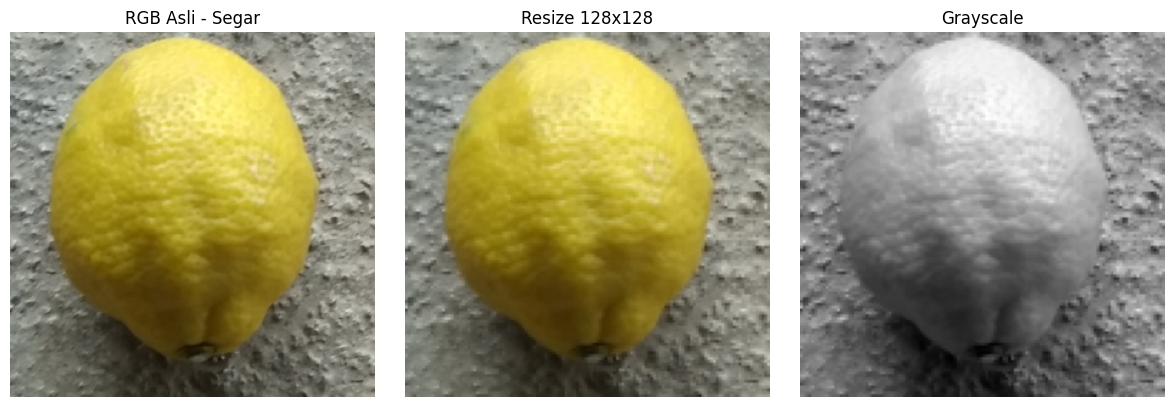

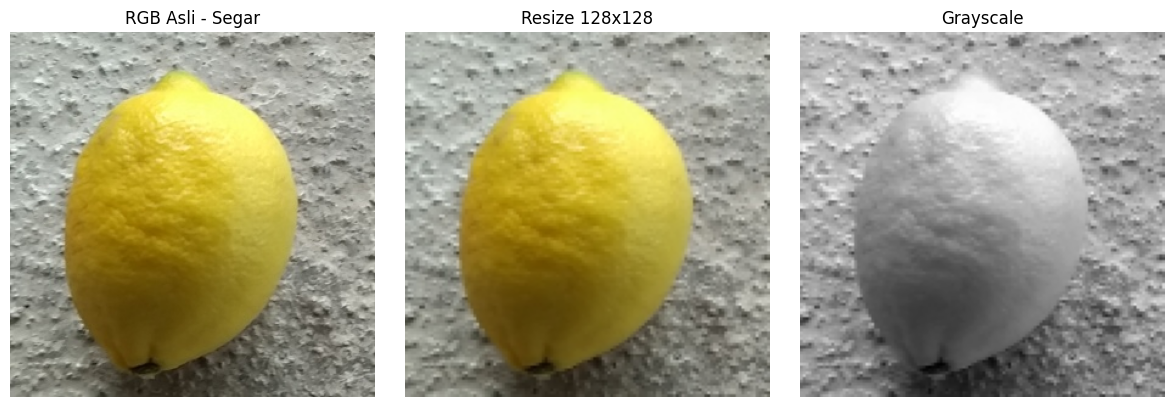

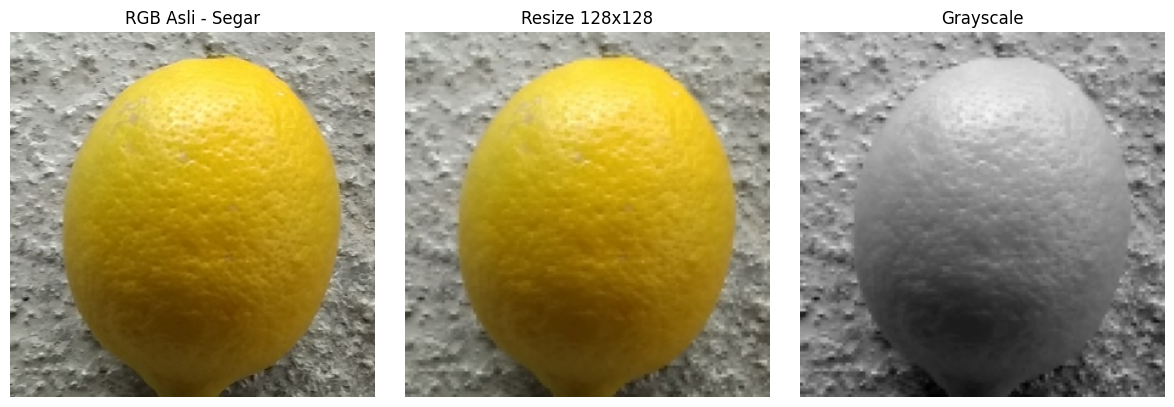

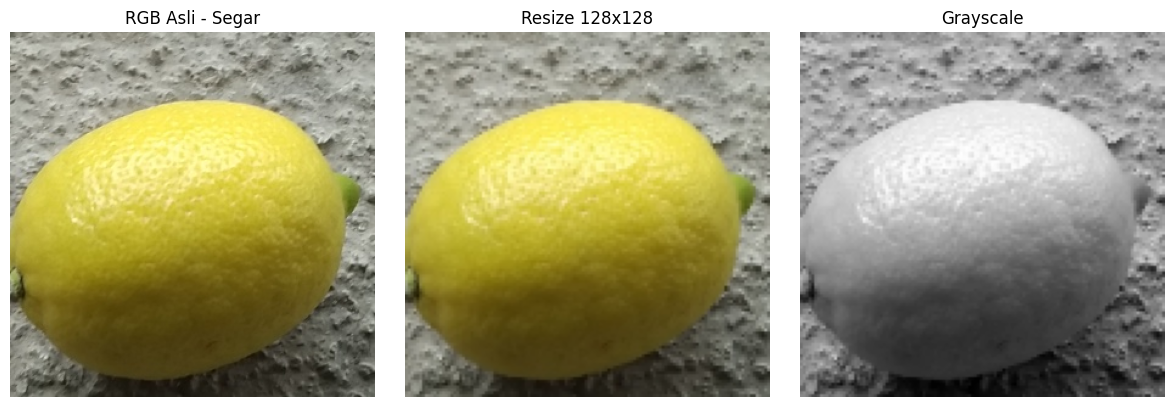

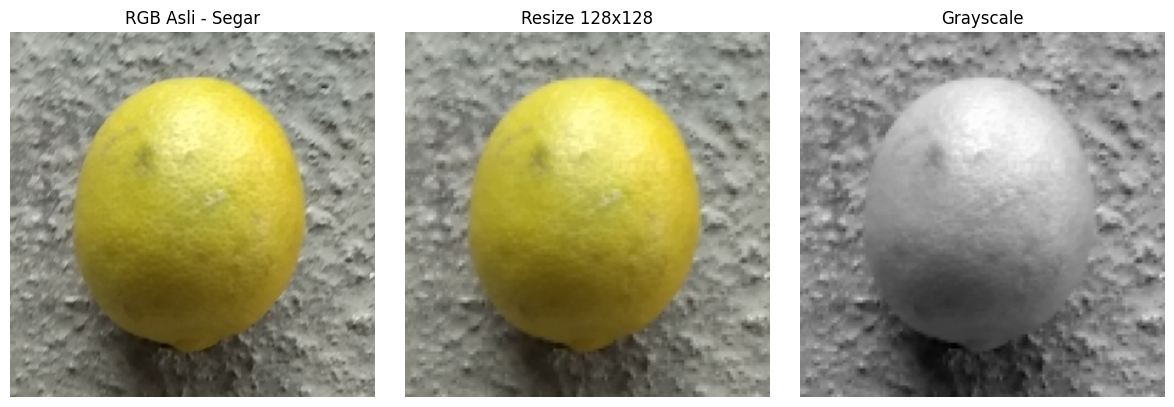

In [40]:
import matplotlib.pyplot as plt

image_path = '/content/drive/MyDrive/SEMESTER 6/COMVIS/UTS/lemon_dataset/good_quality'

for i in range(5):  # tampilkan 5 gambar
    img_name = os.listdir(image_path)[i]
    img_file = os.path.join(image_path, img_name)

    img_color = cv2.imread(img_file)
    img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
    img_resize = cv2.resize(img_color, (128,128))
    img_gray = cv2.cvtColor(img_resize, cv2.COLOR_RGB2GRAY)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_color)
    plt.title(f"RGB Asli - Segar")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(img_resize)
    plt.title("Resize 128x128")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Grayscale")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# **10.Model KNN**

In [33]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()

# **11.Prediksi & Evaluasi Model**

In [34]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Akurasi: 0.8918269230769231
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       185
           1       0.90      0.90      0.90       231

    accuracy                           0.89       416
   macro avg       0.89      0.89      0.89       416
weighted avg       0.89      0.89      0.89       416



# **11.Confusion Matrix**

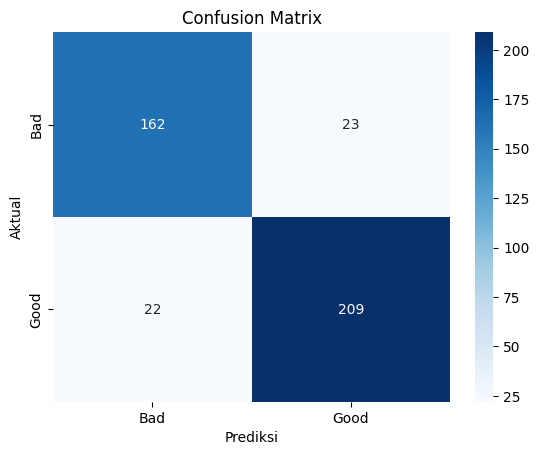

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bad', 'Good'],
            yticklabels=['Bad', 'Good'])

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

# **12.Menyimpan Label**

In [36]:
import os

data = []
labels = []

base_path = '/content/drive/MyDrive/SEMESTER 6/COMVIS/UTS/lemon_dataset'

for label in ['good_quality', 'bad_quality']:
    folder_path = os.path.join(base_path, label)
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        img = cv2.imread(img_path)
        if img is None:
            continue
        hsv = extract_hsv(img_path)
        glcm = extract_glcm(img_path)
        features = hsv + glcm
        data.append(features)
        if label == 'good_quality':
            labels.append(1)
        else:
            labels.append(0)